# RNN

Проверяю рекуррентную модель на тех же подготовленных наборах признаков и той же валидационной части.

In [ ]:
from pathlib import Path

import gc
import os
import random
import pickle
import warnings

for warn in [UserWarning, FutureWarning]:
    warnings.filterwarnings("ignore", category=warn)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score  # классы несбалансированы
from sklearn.metrics import average_precision_score  # положительный класс -- редкий
from sklearn.metrics import balanced_accuracy_score  # accuracy для дисбаланса
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", DEVICE)

PROJECT_DIR = Path("/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton")
DATA_DIR = PROJECT_DIR / "data"
BASE_DIR = DATA_DIR

LOGS_DIR = PROJECT_DIR / "logs" / "rnn_optuna_log"
MODELS_DIR = PROJECT_DIR / "models" / "rnn_models"
SUBMISSIONS_DIR = PROJECT_DIR / "submissions"

LOGS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("BASE_DIR:", BASE_DIR)
print("LOGS_DIR:", LOGS_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("SUBMISSIONS_DIR:", SUBMISSIONS_DIR)

optuna.logging.set_verbosity(optuna.logging.WARNING)

Device: mps
PROJECT_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton
BASE_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data
LOGS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/logs/rnn_optuna_log
MODELS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/rnn_models
SUBMISSIONS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/submissions


## Загрузка данных

In [ ]:
feature_sets = [
    "top300",
    "top500_clean",
    "top500_lgb_clean",
    "top500_magic_meta",
    "top500_micro_engineered",
]


def resolve_feature_path(folder, split):
    file_name = f"X_{split}_{folder}.parquet"
    candidates = [
        BASE_DIR / folder / file_name,
        BASE_DIR / file_name,
        BASE_DIR / "processed_data" / folder / file_name,
        BASE_DIR / "processed_data" / file_name,
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Не нашел файл с признаками. Проверенные пути:\n"
        + "\n".join(str(path) for path in candidates)
    )


def resolve_target_path(name):
    candidates = [
        BASE_DIR / f"y_{name}.parquet",
        BASE_DIR / "processed_data" / f"y_{name}.parquet",
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Не нашел target-файл. Проверенные пути:\n"
        + "\n".join(str(path) for path in candidates)
    )


def read_feature_matrix(folder, split):
    path = resolve_feature_path(folder, split)
    print(f"read {split:<13} {folder:<25} -> {path}")
    return pd.read_parquet(path)


def read_target(name):
    path = resolve_target_path(name)
    print(f"read target {name:<13} -> {path}")
    return pd.read_parquet(path).iloc[:, 0].values.ravel()


def check_feature_sets():
    rows = []
    for folder in feature_sets:
        row = {"feature_set": folder}
        for split in ["train_sampled", "train_full", "val", "test"]:
            try:
                row[split] = resolve_feature_path(folder, split).exists()
            except FileNotFoundError:
                row[split] = False
        rows.append(row)

    return pd.DataFrame(rows)

check_feature_sets()

,feature_set,train_sampled,train_full,val,test
0,top300,True,True,True,True
1,top500_clean,True,True,True,True
2,top500_lgb_clean,True,True,True,True
3,top500_magic_meta,True,True,True,True
4,top500_micro_engineered,True,True,True,True


## Метрики и подбор порога

In [ ]:
def count_metrics(y_true, y_pred, y_score):
    """
    roc_auc_score: вероятность того, что модель присвоит случайному объекту класса 1 более высокий score, чем случайному объекту класса 0; чем ближе к 1, тем лучше разделение классов, 0.5 — уровень случайного угадывания.

    average_precision_score: среднее качество поиска объектов класса 1 по всем возможным порогам; высокая метрика означает, что среди объектов, которые модель считает наиболее похожими на класс 1, действительно много единиц.

    balanced_accuracy_score: средняя точность отдельно по классу 0 и по классу 1; полезна при дисбалансе классов, потому что не дает модели выглядеть хорошей только за счет угадывания самого частого класса.

    f1_score: одна итоговая оценка качества предсказания класса 1, которая будет высокой только тогда, когда модель одновременно находит много настоящих единиц и не слишком часто ошибочно объявляет нули единицами.
    """

    print("roc auc:", roc_auc_score(y_true, y_score))
    print("average precision:", average_precision_score(y_true, y_score))
    print("balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("f1:", f1_score(y_true, y_pred, zero_division=0))


def best_f1_threshold(y_true, y_score):
    """Подбираем порог по train-score, чтобы .predict() с 0.5 не превращал всё в нули.

    ROC AUC при этом не меняется: он считается по y_score, а не по бинарному y_pred.
    """

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    precision = precision[:-1]
    recall = recall[:-1]

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    if len(thresholds) == 0:
        return 0.5

    return thresholds[np.argmax(f1)]


def predict_with_threshold(y_score, threshold):
    return (y_score >= threshold).astype(int)

## Подготовка матриц

In [ ]:
def prepare_matrices(X_train, X_val):
    scaler = StandardScaler()

    X_train_np = X_train.to_numpy(dtype=np.float32, copy=True)
    X_val_np = X_val.to_numpy(dtype=np.float32, copy=True)

    X_train_np = np.nan_to_num(X_train_np, nan=0.0, posinf=0.0, neginf=0.0)
    X_val_np = np.nan_to_num(X_val_np, nan=0.0, posinf=0.0, neginf=0.0)

    X_train_np = scaler.fit_transform(X_train_np).astype(np.float32)
    X_val_np = scaler.transform(X_val_np).astype(np.float32)

    return X_train_np, X_val_np, scaler


def count_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)

## Архитектура модели

In [ ]:
MODEL_NAME = "RNN"
MODEL_PREFIX = "rnn"


def pad_features(X, seq_feature_size):
    n_objects, n_features = X.shape
    pad_size = (-n_features) % seq_feature_size

    if pad_size > 0:
        X = np.pad(X, ((0, 0), (0, pad_size)), mode="constant")

    seq_len = X.shape[1] // seq_feature_size
    return X.reshape(n_objects, seq_len, seq_feature_size).astype(np.float32)


def make_loader(X, y, batch_size, shuffle, params):
    X_seq = pad_features(X, params["seq_feature_size"])
    x_tensor = torch.from_numpy(X_seq)
    y_tensor = torch.from_numpy(y.astype(np.float32)).view(-1, 1)
    dataset = TensorDataset(x_tensor, y_tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        drop_last=shuffle,
    )


def make_loader_for_prediction(X, batch_size, params):
    X_seq = pad_features(X, params["seq_feature_size"])
    x_tensor = torch.from_numpy(X_seq)
    y_tensor = torch.zeros((len(X_seq), 1), dtype=torch.float32)
    dataset = TensorDataset(x_tensor, y_tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


class TabularRNN(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.1, nonlinearity="tanh"):
        super(TabularRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=nonlinearity,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.rnn(x, h0)
        return self.head(out[:, -1, :])


def make_model(input_dim, params):
    seq_feature_size = params["seq_feature_size"]
    padded_dim = input_dim + ((-input_dim) % seq_feature_size)
    input_size = seq_feature_size

    return TabularRNN(
        input_size=input_size,
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        nonlinearity=params["nonlinearity"],
    ).to(DEVICE)

## Обучение модели

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)

    total_loss = 0.0
    all_scores = []
    all_targets = []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            if train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(x_batch)

            scores = torch.sigmoid(logits).detach().cpu().numpy().ravel()
            targets = y_batch.detach().cpu().numpy().ravel()
            all_scores.append(scores)
            all_targets.append(targets)

    all_scores = np.concatenate(all_scores)
    all_targets = np.concatenate(all_targets)
    auc = roc_auc_score(all_targets, all_scores)
    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, auc


def train_model(model, train_loader, val_loader, criterion, optimizer, max_epochs=10, patience=2):
    best_auc = -np.inf
    best_state = None
    history = []
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        train_loss, train_auc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_auc = run_epoch(model, val_loader, criterion)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_auc": train_auc,
                "val_loss": val_loss,
                "val_auc": val_auc,
            }
        )

        print(
            f"epoch {epoch:02d}/{max_epochs} | "
            f"train loss {train_loss:.5f} auc {train_auc:.5f} | "
            f"val loss {val_loss:.5f} auc {val_auc:.5f}"
        )

        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_auc, history, best_state


def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


@torch.no_grad()
def predict_scores(model, loader):
    model.eval()
    all_scores = []

    for x_batch, _ in loader:
        x_batch = x_batch.to(DEVICE)
        logits = model(x_batch)
        scores = torch.sigmoid(logits).detach().cpu().numpy().ravel()
        all_scores.append(scores)

    return np.concatenate(all_scores)

## Функция для оптимизации параметров с помощью optuna

In [ ]:
def objective(trial, X_train, y_train, X_val, y_val, max_epochs, patience):
    params = {
        "seq_feature_size": trial.suggest_categorical("seq_feature_size", [4, 8, 16]),
        "hidden_size": trial.suggest_categorical("hidden_size", [48, 64, 96, 128]),
        "num_layers": trial.suggest_int("num_layers", 1, 2),
        "dropout": trial.suggest_float("dropout", 0.0, 0.35),
        "nonlinearity": trial.suggest_categorical("nonlinearity", ["tanh", "relu"]),
        "lr": trial.suggest_float("lr", 1e-4, 2e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 2048, 4096]),
        "pos_weight_mult": trial.suggest_float("pos_weight_mult", 0.5, 1.5),
    }

    train_loader = make_loader(X_train, y_train, params["batch_size"], shuffle=True, params=params)
    val_loader = make_loader(X_val, y_val, params["batch_size"], shuffle=False, params=params)

    model = make_model(X_train.shape[1], params)

    pos_count = np.maximum(y_train.sum(), 1)
    neg_count = len(y_train) - y_train.sum()
    pos_weight = (neg_count / pos_count) * params["pos_weight_mult"]
    pos_weight = torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )

    best_auc, history, _ = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        max_epochs=max_epochs,
        patience=patience,
    )

    trial.set_user_attr("n_params", count_parameters(model))
    trial.set_user_attr("last_epoch", history[-1]["epoch"])

    del model, train_loader, val_loader, criterion, optimizer
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return best_auc

In [ ]:
def logging_callback(study, trial):
    set_name = study.user_attrs.get("set_name", "unknown")
    train_mode = study.user_attrs.get("train_mode", "unknown")
    log_file_path = LOGS_DIR / f"{set_name}_{train_mode}_optimization.log"

    with open(log_file_path, "a") as f:
        f.write(
            f"Trial {trial.number:03d} finished | "
            f"ROC-AUC: {trial.value:.5f} | "
            f"Best ROC-AUC so far: {study.best_value:.5f}\n"
        )

## Подбор параметров на усеченной обучающей выборке

In [ ]:
OPTUNA_N_TRIALS_SAMPLED = 20
OPTUNA_TIMEOUT_SAMPLED = 1800
SAMPLED_MAX_EPOCHS = 6
SAMPLED_PATIENCE = 2

y_train_sampled = read_target("train_sampled")
y_val = read_target("val")

best_params_sampled = {}
best_scores_sampled = {}

read target train_sampled -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/y_train_sampled.parquet
read target val           -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/y_val.parquet


In [ ]:
for folder in feature_sets:
    print(f"\n==================================================")
    print(f" НАЧАЛО ОПТИМИЗАЦИИ НАБОРА: {folder}")
    print(f"==================================================")

    X_train_sampled = read_feature_matrix(folder, "train_sampled")
    X_val = read_feature_matrix(folder, "val")

    assert len(X_train_sampled) == len(y_train_sampled)
    assert len(X_val) == len(y_val)

    X_train_sampled_np, X_val_np, _ = prepare_matrices(X_train_sampled, X_val)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.set_user_attr("set_name", folder)
    study.set_user_attr("train_mode", "sampled")

    log_file_path = LOGS_DIR / f"{folder}_sampled_optimization.log"
    if log_file_path.exists():
        log_file_path.unlink()

    study.optimize(
        lambda trial: objective(
            trial,
            X_train_sampled_np,
            y_train_sampled,
            X_val_np,
            y_val,
            max_epochs=SAMPLED_MAX_EPOCHS,
            patience=SAMPLED_PATIENCE,
        ),
        n_trials=OPTUNA_N_TRIALS_SAMPLED,
        timeout=OPTUNA_TIMEOUT_SAMPLED,
        callbacks=[logging_callback],
        show_progress_bar=True,
    )

    best_params_sampled[folder] = study.best_params
    best_scores_sampled[folder] = study.best_value

    print(f"\n УСПЕШНО ЗАВЕРШЕНО ДЛЯ: {folder}")
    print(f" Лучший ROC-AUC на валидации: {study.best_value:.5f}")
    print(f" Подробный лог сохранен в: {log_file_path}")
    print(" Лучшие параметры:")
    for param, value in study.best_params.items():
        print(f"   -> {param}: {value}")

    del X_train_sampled, X_val, X_train_sampled_np, X_val_np, study
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("\n\n==================================================")
print(" ОПТИМИЗАЦИЯ НА УСЕЧЕННЫХ ВЫБОРКАХ ЗАВЕРШЕНА!")
print("==================================================")


 НАЧАЛО ОПТИМИЗАЦИИ НАБОРА: top300
read train_sampled top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_train_sampled_top300.parquet
read val           top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_val_top300.parquet


  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/6 | train loss 1.38170 auc 0.49997 | val loss 0.91985 auc 0.53750
epoch 02/6 | train loss 1.33335 auc 0.52902 | val loss 0.91971 auc 0.55486
epoch 03/6 | train loss 1.32643 auc 0.54251 | val loss 0.88510 auc 0.55552
epoch 04/6 | train loss 1.31706 auc 0.55925 | val loss 0.86082 auc 0.56383
epoch 05/6 | train loss 1.31060 auc 0.57515 | val loss 0.87904 auc 0.57222
epoch 06/6 | train loss 1.30948 auc 0.57694 | val loss 0.86898 auc 0.56985
epoch 01/6 | train loss 1.52385 auc 0.50889 | val loss 0.98088 auc 0.53664
epoch 02/6 | train loss 1.49581 auc 0.53342 | val loss 1.03309 auc 0.55379
epoch 03/6 | train loss 1.48783 auc 0.55104 | val loss 1.00684 auc 0.56043
epoch 04/6 | train loss 1.48217 auc 0.56170 | val loss 1.00990 auc 0.56152
epoch 05/6 | train loss 1.47873 auc 0.56683 | val loss 1.01172 auc 0.56628
epoch 06/6 | train loss 1.47587 auc 0.56844 | val loss 1.00009 auc 0.56635
epoch 01/6 | train loss 1.54653 auc 0.54489 | val loss 1.07440 auc 0.56668
epoch 02/6 | train loss 1

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/6 | train loss 1.36837 auc 0.50563 | val loss 0.82094 auc 0.48267
epoch 02/6 | train loss 1.33841 auc 0.50091 | val loss 0.89479 auc 0.52257
epoch 03/6 | train loss 1.32725 auc 0.52477 | val loss 0.83174 auc 0.52536
epoch 04/6 | train loss 1.32802 auc 0.52296 | val loss 0.82286 auc 0.52664
epoch 05/6 | train loss 1.32728 auc 0.52691 | val loss 0.83596 auc 0.52985
epoch 06/6 | train loss 1.31934 auc 0.54868 | val loss 0.88340 auc 0.53138
epoch 01/6 | train loss 1.50896 auc 0.51048 | val loss 1.02658 auc 0.50750
epoch 02/6 | train loss 1.50085 auc 0.51251 | val loss 1.01774 auc 0.50057
epoch 03/6 | train loss 1.48885 auc 0.53313 | val loss 1.00174 auc 0.50784
epoch 04/6 | train loss 1.48828 auc 0.53848 | val loss 1.01852 auc 0.51815
epoch 05/6 | train loss 1.48536 auc 0.54765 | val loss 1.00015 auc 0.53018
epoch 06/6 | train loss 1.48777 auc 0.54342 | val loss 1.02220 auc 0.52501
epoch 01/6 | train loss 1.55673 auc 0.51443 | val loss 1.14314 auc 0.52964
epoch 02/6 | train loss 1

...

epoch 01/6 | train loss 1.35424 auc 0.50353 | val loss 0.85793 auc 0.53652
epoch 02/6 | train loss 1.33149 auc 0.51649 | val loss 0.86703 auc 0.54410
epoch 03/6 | train loss 1.32373 auc 0.53933 | val loss 0.88128 auc 0.54961
epoch 04/6 | train loss 1.31839 auc 0.55529 | val loss 0.85732 auc 0.54241
epoch 05/6 | train loss 1.31775 auc 0.55604 | val loss 0.85019 auc 0.54505
epoch 01/6 | train loss 1.64528 auc 0.50351 | val loss 1.06397 auc 0.49572
epoch 02/6 | train loss 1.51653 auc 0.50055 | val loss 1.02928 auc 0.51414
epoch 03/6 | train loss 1.49873 auc 0.51589 | val loss 1.01776 auc 0.51928
epoch 04/6 | train loss 1.49202 auc 0.52945 | val loss 1.01465 auc 0.52188
epoch 05/6 | train loss 1.49397 auc 0.52847 | val loss 1.03410 auc 0.52498
epoch 06/6 | train loss 1.48712 auc 0.53736 | val loss 0.99556 auc 0.52783
epoch 01/6 | train loss 1.55759 auc 0.53111 | val loss 1.07414 auc 0.55127
epoch 02/6 | train loss 1.53666 auc 0.54758 | val loss 1.07046 auc 0.55879
epoch 03/6 | train loss 1

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/6 | train loss 1.34826 auc 0.51800 | val loss 0.86080 auc 0.54768
epoch 02/6 | train loss 1.32370 auc 0.53781 | val loss 0.87429 auc 0.53787
epoch 03/6 | train loss 1.32019 auc 0.54628 | val loss 0.89924 auc 0.53797
epoch 01/6 | train loss 1.49393 auc 0.53449 | val loss 1.02825 auc 0.53040
epoch 02/6 | train loss 1.48794 auc 0.54459 | val loss 0.98831 auc 0.54253
epoch 03/6 | train loss 1.48298 auc 0.55790 | val loss 1.03438 auc 0.54939
epoch 04/6 | train loss 1.48275 auc 0.55104 | val loss 1.00233 auc 0.55200
epoch 05/6 | train loss 1.48080 auc 0.55439 | val loss 1.00818 auc 0.55220
epoch 06/6 | train loss 1.47747 auc 0.56356 | val loss 1.04049 auc 0.55509
epoch 01/6 | train loss 1.54285 auc 0.53743 | val loss 0.98641 auc 0.55796
epoch 02/6 | train loss 1.52512 auc 0.56618 | val loss 1.13365 auc 0.55154
epoch 03/6 | train loss 1.52034 auc 0.57483 | val loss 0.99609 auc 0.54837
epoch 01/6 | train loss 1.10989 auc 0.51742 | val loss 0.63898 auc 0.52470
epoch 02/6 | train loss 1

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/6 | train loss 1.35684 auc 0.51695 | val loss 0.90533 auc 0.53014
epoch 02/6 | train loss 1.33279 auc 0.52598 | val loss 0.86881 auc 0.54045
epoch 03/6 | train loss 1.32803 auc 0.53236 | val loss 0.85473 auc 0.54550
epoch 04/6 | train loss 1.32289 auc 0.54621 | val loss 0.83494 auc 0.54395
epoch 05/6 | train loss 1.31538 auc 0.56160 | val loss 0.83453 auc 0.55269
epoch 06/6 | train loss 1.31565 auc 0.56200 | val loss 0.85931 auc 0.55440
epoch 01/6 | train loss 1.65324 auc 0.50332 | val loss 0.94766 auc 0.49584
epoch 02/6 | train loss 1.51170 auc 0.50975 | val loss 1.06164 auc 0.51733
epoch 03/6 | train loss 1.49491 auc 0.52761 | val loss 0.97859 auc 0.52585
epoch 04/6 | train loss 1.49258 auc 0.53469 | val loss 1.04992 auc 0.53413
epoch 05/6 | train loss 1.48893 auc 0.53805 | val loss 0.99906 auc 0.54122
epoch 06/6 | train loss 1.48362 auc 0.55557 | val loss 1.03244 auc 0.54560
epoch 01/6 | train loss 1.56020 auc 0.52859 | val loss 0.98340 auc 0.55337
epoch 02/6 | train loss 1

In [ ]:
sampled_results_df = pd.DataFrame(
    [
        {
            "feature_set": folder,
            "best_roc_auc": best_scores_sampled[folder],
            "best_params": best_params_sampled[folder],
        }
        for folder in feature_sets
    ]
).sort_values("best_roc_auc", ascending=False).reset_index(drop=True)

sampled_results_df

,feature_set,best_roc_auc,best_params
0,top300,0.616890,"{'seq_feature_size': 16, 'hidden_size': 96, 'n..."
1,top500_clean,0.585460,"{'seq_feature_size': 16, 'hidden_size': 96, 'n..."
2,top500_micro_engineered,0.580770,"{'seq_feature_size': 16, 'hidden_size': 96, 'n..."
3,top500_lgb_clean,0.573933,"{'seq_feature_size': 16, 'hidden_size': 96, 'n..."
4,top500_magic_meta,0.570571,"{'seq_feature_size': 16, 'hidden_size': 128, '..."


## Подбор параметров на полной обучающей выборке

In [ ]:
OPTUNA_N_TRIALS_FULL = 20
OPTUNA_TIMEOUT_FULL = 1800
FULL_MAX_EPOCHS = 8
FULL_PATIENCE = 2

y_train_full = read_target("train_full")
y_val = read_target("val")

best_params_per_set = {}
best_scores_per_set = {}

read target train_full    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/y_train_full.parquet
read target val           -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/y_val.parquet


In [ ]:
for folder in feature_sets:
    print(f"\n==================================================")
    print(f" НАЧАЛО ОПТИМИЗАЦИИ НАБОРА: {folder}")
    print(f"==================================================")

    X_train_full = read_feature_matrix(folder, "train_full")
    X_val = read_feature_matrix(folder, "val")

    assert len(X_train_full) == len(y_train_full)
    assert len(X_val) == len(y_val)

    X_train_full_np, X_val_np, _ = prepare_matrices(X_train_full, X_val)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.set_user_attr("set_name", folder)
    study.set_user_attr("train_mode", "full")

    log_file_path = LOGS_DIR / f"{folder}_full_optimization.log"
    if log_file_path.exists():
        log_file_path.unlink()

    study.optimize(
        lambda trial: objective(
            trial,
            X_train_full_np,
            y_train_full,
            X_val_np,
            y_val,
            max_epochs=FULL_MAX_EPOCHS,
            patience=FULL_PATIENCE,
        ),
        n_trials=OPTUNA_N_TRIALS_FULL,
        timeout=OPTUNA_TIMEOUT_FULL,
        callbacks=[logging_callback],
        show_progress_bar=True,
    )

    best_params_per_set[folder] = study.best_params
    best_scores_per_set[folder] = study.best_value

    print(f"\n УСПЕШНО ЗАВЕРШЕНО ДЛЯ: {folder}")
    print(f" Лучший ROC-AUC на валидации: {study.best_value:.5f}")
    print(f" Подробный лог сохранен в: {log_file_path}")
    print(" Лучшие параметры:")
    for param, value in study.best_params.items():
        print(f"   -> {param}: {value}")

    del X_train_full, X_val, X_train_full_np, X_val_np, study
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("\n\n==================================================")
print(" ОПТИМИЗАЦИЯ НА ПОЛНОМ TRAIN ЗАВЕРШЕНА!")
print("==================================================")


 НАЧАЛО ОПТИМИЗАЦИИ НАБОРА: top300
read train_full    top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_train_full_top300.parquet
read val           top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_val_top300.parquet


  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/8 | train loss 1.38612 auc 0.52760 | val loss 1.37924 auc 0.55301
epoch 02/8 | train loss 1.36685 auc 0.55872 | val loss 1.37290 auc 0.55480
epoch 03/8 | train loss 1.35985 auc 0.56856 | val loss 1.37083 auc 0.55921
epoch 04/8 | train loss 1.35288 auc 0.57972 | val loss 1.37265 auc 0.56257
epoch 05/8 | train loss 1.34556 auc 0.58773 | val loss 1.37123 auc 0.56947
epoch 06/8 | train loss 1.34759 auc 0.59094 | val loss 1.36802 auc 0.58268
epoch 07/8 | train loss 1.34305 auc 0.59771 | val loss 1.36054 auc 0.58565
epoch 08/8 | train loss 1.33648 auc 0.60364 | val loss 1.36808 auc 0.57507
epoch 01/8 | train loss 1.57570 auc 0.49881 | val loss 1.55658 auc 0.53401
epoch 02/8 | train loss 1.53542 auc 0.54682 | val loss 1.55002 auc 0.55439
epoch 03/8 | train loss 1.52810 auc 0.57027 | val loss 1.54393 auc 0.56176
epoch 04/8 | train loss 1.52197 auc 0.58098 | val loss 1.54136 auc 0.56830
epoch 05/8 | train loss 1.51448 auc 0.58456 | val loss 1.54894 auc 0.56701
epoch 06/8 | train loss 1

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/8 | train loss 1.39108 auc 0.50589 | val loss 1.38875 auc 0.52080
epoch 02/8 | train loss 1.37295 auc 0.52155 | val loss 1.38392 auc 0.51767
epoch 03/8 | train loss 1.37172 auc 0.52705 | val loss 1.37923 auc 0.53916
epoch 04/8 | train loss 1.37119 auc 0.53569 | val loss 1.38283 auc 0.53473
epoch 05/8 | train loss 1.36640 auc 0.54691 | val loss 1.37985 auc 0.54239
epoch 06/8 | train loss 1.36180 auc 0.55627 | val loss 1.37826 auc 0.54551
epoch 07/8 | train loss 1.36068 auc 0.56490 | val loss 1.38434 auc 0.53624
epoch 08/8 | train loss 1.36116 auc 0.56247 | val loss 1.38668 auc 0.52947
epoch 01/8 | train loss 1.55528 auc 0.51692 | val loss 1.56578 auc 0.49742
epoch 02/8 | train loss 1.55078 auc 0.52639 | val loss 1.56004 auc 0.51596
epoch 03/8 | train loss 1.54061 auc 0.53884 | val loss 1.56106 auc 0.51856
epoch 04/8 | train loss 1.53084 auc 0.55331 | val loss 1.55663 auc 0.53016
epoch 05/8 | train loss 1.53073 auc 0.56233 | val loss 1.55998 auc 0.53293
epoch 06/8 | train loss 1

...

epoch 01/8 | train loss 1.39597 auc 0.50883 | val loss 1.38007 auc 0.53858
epoch 02/8 | train loss 1.37845 auc 0.51945 | val loss 1.38333 auc 0.53184
epoch 03/8 | train loss 1.36371 auc 0.55285 | val loss 1.39415 auc 0.54520
epoch 04/8 | train loss 1.35872 auc 0.55974 | val loss 1.37641 auc 0.55316
epoch 05/8 | train loss 1.35849 auc 0.56528 | val loss 1.37286 auc 0.56179
epoch 06/8 | train loss 1.35755 auc 0.56750 | val loss 1.37760 auc 0.55234
epoch 07/8 | train loss 1.35302 auc 0.57210 | val loss 1.38745 auc 0.55556
epoch 01/8 | train loss 1.58670 auc 0.50219 | val loss 1.56091 auc 0.50703
epoch 02/8 | train loss 1.54154 auc 0.53936 | val loss 1.55548 auc 0.52740
epoch 03/8 | train loss 1.53753 auc 0.54917 | val loss 1.55189 auc 0.53343
epoch 04/8 | train loss 1.53497 auc 0.54623 | val loss 1.55208 auc 0.53380
epoch 05/8 | train loss 1.52803 auc 0.56182 | val loss 1.55723 auc 0.53380
epoch 06/8 | train loss 1.52908 auc 0.56293 | val loss 1.55273 auc 0.53397
epoch 07/8 | train loss 1

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/8 | train loss 1.40360 auc 0.51473 | val loss 1.38757 auc 0.54622
epoch 02/8 | train loss 1.37454 auc 0.53279 | val loss 1.38552 auc 0.53603
epoch 03/8 | train loss 1.36809 auc 0.54184 | val loss 1.39028 auc 0.53686
epoch 01/8 | train loss 1.56456 auc 0.50513 | val loss 1.55963 auc 0.53783
epoch 02/8 | train loss 1.53615 auc 0.54631 | val loss 1.55477 auc 0.53631
epoch 03/8 | train loss 1.53343 auc 0.55577 | val loss 1.55636 auc 0.54126
epoch 04/8 | train loss 1.53000 auc 0.56093 | val loss 1.55006 auc 0.55099
epoch 05/8 | train loss 1.52373 auc 0.56925 | val loss 1.55160 auc 0.55791
epoch 06/8 | train loss 1.52127 auc 0.57588 | val loss 1.54689 auc 0.55972
epoch 07/8 | train loss 1.52179 auc 0.57614 | val loss 1.54443 auc 0.56471
epoch 08/8 | train loss 1.51666 auc 0.58477 | val loss 1.54509 auc 0.56242
epoch 01/8 | train loss 1.60894 auc 0.54125 | val loss 1.62156 auc 0.53894
epoch 02/8 | train loss 1.59377 auc 0.55443 | val loss 1.61184 auc 0.55952
epoch 03/8 | train loss 1

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/8 | train loss 1.38953 auc 0.51167 | val loss 1.38506 auc 0.52220
epoch 02/8 | train loss 1.37410 auc 0.52859 | val loss 1.38080 auc 0.53544
epoch 03/8 | train loss 1.37253 auc 0.53584 | val loss 1.38003 auc 0.53948
epoch 04/8 | train loss 1.36770 auc 0.54739 | val loss 1.37954 auc 0.54534
epoch 05/8 | train loss 1.36089 auc 0.56596 | val loss 1.38104 auc 0.54759
epoch 06/8 | train loss 1.35856 auc 0.56548 | val loss 1.37668 auc 0.55407
epoch 07/8 | train loss 1.35769 auc 0.57248 | val loss 1.37770 auc 0.54957
epoch 08/8 | train loss 1.35259 auc 0.57684 | val loss 1.38533 auc 0.54697
epoch 01/8 | train loss 1.55650 auc 0.50883 | val loss 1.55255 auc 0.54141
epoch 02/8 | train loss 1.54423 auc 0.53642 | val loss 1.55232 auc 0.54585
epoch 03/8 | train loss 1.53620 auc 0.54915 | val loss 1.54960 auc 0.55106
epoch 04/8 | train loss 1.53231 auc 0.55886 | val loss 1.54782 auc 0.55500
epoch 05/8 | train loss 1.52310 auc 0.57447 | val loss 1.54708 auc 0.55728
epoch 06/8 | train loss 1

In [ ]:
full_results_df = pd.DataFrame(
    [
        {
            "feature_set": folder,
            "best_roc_auc": best_scores_per_set[folder],
            "best_params": best_params_per_set[folder],
        }
        for folder in feature_sets
    ]
).sort_values("best_roc_auc", ascending=False).reset_index(drop=True)

full_results_df

,feature_set,best_roc_auc,best_params
0,top300,0.627553,"{'seq_feature_size': 16, 'hidden_size': 96, 'n..."
1,top500_clean,0.600639,"{'seq_feature_size': 16, 'hidden_size': 96, 'n..."
2,top500_micro_engineered,0.588214,"{'seq_feature_size': 16, 'hidden_size': 96, 'n..."
3,top500_magic_meta,0.581040,"{'seq_feature_size': 16, 'hidden_size': 96, 'n..."
4,top500_lgb_clean,0.578307,"{'seq_feature_size': 16, 'hidden_size': 64, 'n..."


## Финальное обучение моделей с лучшими параметрами на полной обучающей выборке

In [ ]:
FINAL_MAX_EPOCHS = 12
FINAL_PATIENCE = 3

final_val_scores = {}
final_thresholds = {}
saved_model_paths = {}
final_metrics_rows = []

In [ ]:
for folder, params in best_params_per_set.items():
    print(f"\n==================================================")
    print(f" ФИНАЛЬНОЕ ОБУЧЕНИЕ НА ПОЛНОМ ТРЕЙНЕ: {folder}")
    print(f"==================================================")

    X_train_full = read_feature_matrix(folder, "train_full")
    X_val = read_feature_matrix(folder, "val")

    assert len(X_train_full) == len(y_train_full)
    assert len(X_val) == len(y_val)

    X_train_full_np, X_val_np, scaler = prepare_matrices(X_train_full, X_val)

    train_loader = make_loader(X_train_full_np, y_train_full, params["batch_size"], shuffle=True, params=params)
    train_eval_loader = make_loader(X_train_full_np, y_train_full, params["batch_size"], shuffle=False, params=params)
    val_loader = make_loader(X_val_np, y_val, params["batch_size"], shuffle=False, params=params)

    final_model = make_model(X_train_full_np.shape[1], params)
    print("params:", f"{count_parameters(final_model):,}")

    pos_count = np.maximum(y_train_full.sum(), 1)
    neg_count = len(y_train_full) - y_train_full.sum()
    pos_weight = (neg_count / pos_count) * params["pos_weight_mult"]
    pos_weight = torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(
        final_model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )

    current_score, history, best_state = train_model(
        final_model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        max_epochs=FINAL_MAX_EPOCHS,
        patience=FINAL_PATIENCE,
    )

    y_score_train = predict_scores(final_model, train_eval_loader)
    threshold = best_f1_threshold(y_train_full, y_score_train)

    y_score_val = predict_scores(final_model, val_loader)
    y_pred_val = predict_with_threshold(y_score_val, threshold)

    final_val_scores[folder] = current_score
    final_thresholds[folder] = threshold

    print(f"{MODEL_NAME} threshold: {threshold}")
    count_metrics(y_val, y_pred_val, y_score_val)

    model_filename = MODELS_DIR / f"{MODEL_PREFIX}_{folder}_{current_score:.5f}.pt"
    torch.save(
        {
            "state_dict": best_state,
            "params": params,
            "input_dim": X_train_full_np.shape[1],
            "feature_set": folder,
            "threshold": threshold,
            "scaler": scaler,
            "history": history,
            "val_roc_auc": current_score,
        },
        model_filename,
    )

    saved_model_paths[folder] = model_filename
    print(f"Модель успешно сохранена: {model_filename}")

    final_metrics_rows.append(
        {
            "feature_set": folder,
            "roc_auc": roc_auc_score(y_val, y_score_val),
            "average_precision": average_precision_score(y_val, y_score_val),
            "balanced_accuracy": balanced_accuracy_score(y_val, y_pred_val),
            "f1": f1_score(y_val, y_pred_val, zero_division=0),
            "threshold": threshold,
            "model_path": str(model_filename),
        }
    )

    del X_train_full, X_val, X_train_full_np, X_val_np, train_loader, train_eval_loader, val_loader
    del final_model, criterion, optimizer, y_score_train, y_score_val, y_pred_val
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("\n\n==================================================")
print(" ОБУЧЕНИЕ И СОХРАНЕНИЕ ВСЕХ МОДЕЛЕЙ ЗАВЕРШЕНЫ!")
print("==================================================")


 ФИНАЛЬНОЕ ОБУЧЕНИЕ НА ПОЛНОМ ТРЕЙНЕ: top300
read train_full    top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_train_full_top300.parquet
read val           top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_val_top300.parquet
params: 11,233
epoch 01/12 | train loss 1.54127 auc 0.55963 | val loss 1.53144 auc 0.57841
epoch 02/12 | train loss 1.52231 auc 0.58442 | val loss 1.54109 auc 0.56437
epoch 03/12 | train loss 1.51199 auc 0.59582 | val loss 1.51022 auc 0.60303
epoch 04/12 | train loss 1.49232 auc 0.62053 | val loss 1.49229 auc 0.62366
epoch 05/12 | train loss 1.49223 auc 0.62142 | val loss 1.50746 auc 0.60410
epoch 06/12 | train loss 1.48082 auc 0.63334 | val loss 1.51657 auc 0.61183
epoch 07/12 | train loss 1.47691 auc 0.63610 | val loss 1.50749 auc 0.62027
RNN threshold: 0.7262654900550842
roc auc: 0.6236589445015861
average precision: 0.022539578605127293
balanced

## Сравнение финальных моделей

In [ ]:
final_results_df = pd.DataFrame(final_metrics_rows).sort_values(
    "roc_auc", ascending=False
).reset_index(drop=True)

final_results_df.style.format(
    {
        "roc_auc": "{:.6f}",
        "average_precision": "{:.6f}",
        "balanced_accuracy": "{:.6f}",
        "f1": "{:.6f}",
        "threshold": "{:.6f}",
    }
)

,feature_set,roc_auc,average_precision,balanced_accuracy,f1,threshold,model_path
0,top300,0.623659,0.022540,0.532819,0.048148,0.726265,/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/rnn_models/rnn_top300_0.62366.pt
1,top500_clean,0.591854,0.019519,0.538666,0.043899,0.669598,/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/rnn_models/rnn_top500_clean_0.59185.pt
2,top500_micro_engineered,0.591600,0.019628,0.536586,0.045016,0.708671,/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/rnn_models/rnn_top500_micro_engineered_0.59160.pt
3,top500_lgb_clean,0.578942,0.017873,0.515102,0.034320,0.707607,/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/rnn_models/rnn_top500_lgb_clean_0.57894.pt
4,top500_magic_meta,0.568594,0.016917,0.511066,0.030899,0.620554,/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/rnn_models/rnn_top500_magic_meta_0.56859.pt


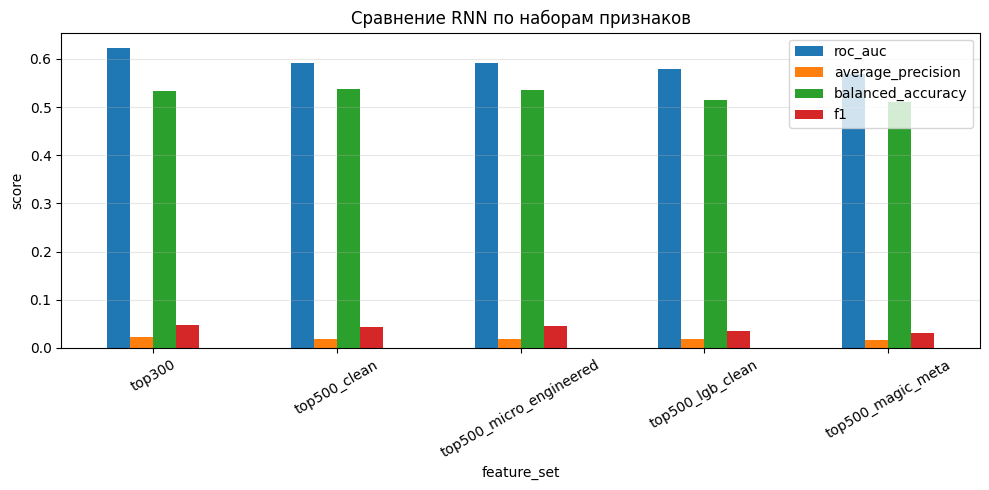

In [ ]:
metrics_to_plot = ["roc_auc", "average_precision", "balanced_accuracy", "f1"]

final_results_df.set_index("feature_set")[metrics_to_plot].plot(
    kind="bar", figsize=(10, 5), rot=30, title=f"Сравнение {MODEL_NAME} по наборам признаков"
)

plt.ylabel("score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
best_folder = final_results_df.loc[0, "feature_set"]
best_model_path = Path(final_results_df.loc[0, "model_path"])

print("best feature set:", best_folder)
print("best model:", best_model_path)
print("best val roc auc:", final_results_df.loc[0, "roc_auc"])
print("best threshold:", final_results_df.loc[0, "threshold"])

best feature set: top300
best model: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/rnn_models/rnn_top300_0.62366.pt
best val roc auc: 0.6236589445015861
best threshold: 0.7262655


## Confusion matrix для лучшей модели

read val           top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_val_top300.parquet


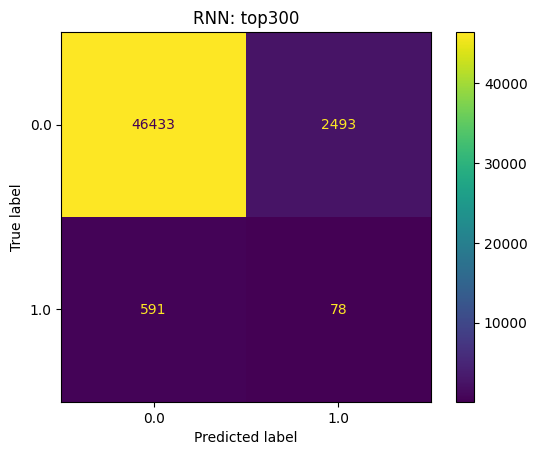

roc auc: 0.6236589445015861
average precision: 0.022539578605127293
balanced accuracy: 0.532818712766365
f1: 0.04814814814814815


In [ ]:
checkpoint = load_checkpoint(best_model_path)
best_params = checkpoint["params"]
scaler = checkpoint["scaler"]

X_val_best = read_feature_matrix(best_folder, "val")
X_val_best_np = X_val_best.to_numpy(dtype=np.float32, copy=True)
X_val_best_np = np.nan_to_num(X_val_best_np, nan=0.0, posinf=0.0, neginf=0.0)
X_val_best_np = scaler.transform(X_val_best_np).astype(np.float32)

val_loader_best = make_loader(X_val_best_np, y_val, best_params["batch_size"], shuffle=False, params=best_params)

best_model = make_model(X_val_best_np.shape[1], best_params).to(DEVICE)
best_model.load_state_dict(checkpoint["state_dict"])

y_score_best = predict_scores(best_model, val_loader_best)
y_pred_best = predict_with_threshold(
    y_score_best, final_thresholds.get(best_folder, final_results_df.loc[0, "threshold"])
)

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_best)
plt.title(f"{MODEL_NAME}: {best_folder}")
plt.show()

count_metrics(y_val, y_pred_best, y_score_best)

del X_val_best, X_val_best_np, val_loader_best, best_model, y_score_best, y_pred_best
gc.collect()
if DEVICE.type == "mps":
    torch.mps.empty_cache()
elif DEVICE.type == "cuda":
    torch.cuda.empty_cache()

## Предсказание для test и сабмит

In [ ]:
RUN_SUBMISSION = True

if RUN_SUBMISSION:
    checkpoint = load_checkpoint(best_model_path)
    best_params = checkpoint["params"]
    scaler = checkpoint["scaler"]

    X_test = read_feature_matrix(best_folder, "test")
    X_test_np = X_test.to_numpy(dtype=np.float32, copy=True)
    X_test_np = np.nan_to_num(X_test_np, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_np = scaler.transform(X_test_np).astype(np.float32)

    test_loader = make_loader_for_prediction(X_test_np, best_params["batch_size"], best_params)

    best_model = make_model(X_test_np.shape[1], best_params).to(DEVICE)
    best_model.load_state_dict(checkpoint["state_dict"])
    test_score = predict_scores(best_model, test_loader)

    submit_candidates = [
        DATA_DIR / "sample_submission.csv",
        DATA_DIR / "submit.csv",
        PROJECT_DIR / "sample_submission.csv",
        PROJECT_DIR / "submit.csv",
    ]
    submit_path = next((path for path in submit_candidates if path.exists()), None)

    if submit_path is not None:
        submission = pd.read_csv(submit_path)
        target_col = "target" if "target" in submission.columns else submission.columns[-1]
        submission[target_col] = test_score
    else:
        submission = pd.DataFrame(
            {
                "index": X_test.index,
                "target": test_score,
            }
        )

    submission_path = SUBMISSIONS_DIR / f"{MODEL_PREFIX}_{best_folder}_{final_results_df.loc[0, 'roc_auc']:.5f}.csv"
    submission.to_csv(submission_path, index=False)

    print("submission saved:", submission_path)
    display(submission.head())

    del X_test, X_test_np, test_loader, best_model, test_score
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

read test          top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_test_top300.parquet
submission saved: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/submissions/rnn_top300_0.62366.csv


,index,score
0,194357,0.469687
1,313222,0.591869
2,321873,0.420138
3,118689,0.733006
4,342561,0.289795
